# Лабораторная работа №5
### Тема: Введение в обучение с подкреплением (RL)
* **Выполнил:** Бумагин П. В.
* **Группа:** ИУ5-22М
* **Преподаватель:** Гапанюк Ю. Е.
* **Задание:** 3 (Выполнение DQN со сверточной нейронной сетью на среде Atari)

---

### 1. Описание задания и среды
**Цель работы:** Реализация алгоритма Deep Q-Network (DQN) на основе сверточной архитектуры для обучения агента игре в Atari.

**Описание среды (Pong-v5):**
В качестве полигона выбрана среда `ALE/Pong-v5` из библиотеки Gymnasium.
* **Состояние (Наблюдение):** Необработанные RGB-кадры экрана игры (разрешение $210 \times 160$ пикселей).
* **Действия:** Дискретное пространство из 6 действий (NOOP, FIRE, RIGHT, LEFT, RIGHTFIRE, LEFTFIRE). По сути, управление ракеткой вверх-вниз.
* **Награда:** $+1$, если мяч пролетел мимо противника; $-1$, если агент пропустил мяч.

**Обоснование архитектуры:**
Для работы со столь многомерным пространством состояний (пикселями) используется Сверточная нейронная сеть (CNN). Для обеспечения марковского свойства (чтобы агент видел направление движения мяча) применяется техника `FrameStack` — объединение 4-х последовательных черно-белых кадров в один тензор $4 \times 84 \times 84$.
Для стабилизации обучения используются:
1. **Replay Buffer (Память воспроизведения):** для разрушения временной корреляции между кадрами.
2. **Target Network (Целевая сеть):** для стабилизации вычисления TD-ошибки (ошибки временных различий).

In [4]:
!pip install gymnasium ale-py
!pip install autorom[accept-rom-license]
!AutoROM --accept-license

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 13.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for AutoROM.accept-rom-license: filename=autorom_accept_rom_license-0.6.1-py3-none-any.whl size=446710 sha256=b969a9702d04567f1cebc625ac8c2fdad9c9c0f36569e28feb9d45941b872a7e
  Stored in directory: /root/.cache/pip/wheels/99/f1/ff/c6966c034a8259164bdc9deb4d1ea839f119474638100e6645
Successfully built AutoROM.accept-rom-license
AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


### Установка зависимостей и импорты

In [5]:
import gymnasium as gym
import ale_py
gym.register_envs(ale_py)
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation as FrameStack
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from itertools import count
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Настройки среды и железа
CONST_ENV_NAME = 'ALE/Pong-v5'
CONST_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {CONST_DEVICE}")

Используем устройство: cuda


### 3. Проектирование сверточной нейронной сети (Nature DQN)

Для аппроксимации функции ценности действий ($Q$-функции) используется сверточная нейросеть. На вход подается тензор размерности $(4, 84, 84)$, представляющий собой стек из 4-х последовательных полутоновых кадров игры, сжатых до разрешения $84 \times 84$.

Архитектура состоит из трех сверточных слоев для извлечения пространственных признаков и двух полносвязных слоев для вычисления вектора $Q(s, a)$.

In [ ]:
class DQN_CNN_Model(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DQN_CNN_Model, self).__init__()
        # Сверточные слои для пикселей
        self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)

        conv_out_size = self._get_conv_out(input_shape)

        # Полносвязные слои для принятия решения
        self.fc1 = nn.Linear(conv_out_size, 512)
        self.fc2 = nn.Linear(512, n_actions)

    def _get_conv_out(self, shape):
        o = self.conv3(F.relu(self.conv2(F.relu(self.conv1(torch.zeros(1, *shape))))))
        return int(np.prod(o.size()))

    def forward(self, x):
        # Нормализация пикселей 0-255 -> 0-1
        x = x.float() / 255.0
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1) # Вытягиваем в вектор
        x = F.relu(self.fc1(x))
        return self.fc2(x)

### 4. Реализация буфера воспроизведения опыта (Experience Replay)

В задачах глубокого RL последовательные кадры сильно коррелированы, что нарушает допущение об независимости и одинаковой распределенности обучающих примеров (i.i.d.).

Для устранения автокорреляции используется класс `ReplayMemory` фиксированной емкости. Переходы сохраняются в формате `uint8` для оптимизации использования оперативной памяти. Обучение сети происходит на случайных батчах, извлекаемых из буфера.

In [ ]:
class ReplayMemory(object):
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, next_state, reward, done):
        # Храним как uint8 для экономии RAM
        self.buffer.append((
            np.array(state, dtype=np.uint8),
            action,
            np.array(next_state, dtype=np.uint8),
            reward,
            done
        ))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, next_states, rewards, dones = zip(*batch)
        return (
            np.array(states),
            np.array(actions),
            np.array(next_states),
            np.array(rewards, dtype=np.float32),
            np.array(dones, dtype=np.uint8)
        )

    def __len__(self):
        return len(self.buffer)

### 5. Разработка управляющего класса DQN-агента

Класс `DQN_Atari_Agent` объединяет все компоненты алгоритма. Агент использует:
1. **$\epsilon$-жадную стратегию** с экспоненциальным затуханием для баланса между исследованием среды (exploration) и эксплуатацией знаний (exploitation).
2. **Плавное обновление целевой сети (Soft Target Update)** с коэффициентом $\tau$ для повышения стабильности обучения.
3. **Функцию потерь Хьюбера (Smooth L1 Loss)** и **ограничение градиентов (Gradient Clipping)** для защиты сети от резких скачков весов при сильных изменениях наград.

In [1]:
class DQN_Atari_Agent:
    def __init__(self, env,
                 BATCH_SIZE = 32,
                 GAMMA = 0.99,
                 EPS_START = 1.0,
                 EPS_END = 0.02,
                 EPS_DECAY = 10000,
                 TAU = 0.005,
                 LR = 1e-4,
                 REPLAY_CAPACITY = 20000,
                 LEARN_START = 5000):

        self.env = env
        self.n_actions = env.action_space.n
        self.input_shape = (4, 84, 84) # 4 склеенных кадра 84x84

        self.BATCH_SIZE = BATCH_SIZE
        self.GAMMA = GAMMA
        self.EPS_START = EPS_START
        self.EPS_END = EPS_END
        self.EPS_DECAY = EPS_DECAY
        self.TAU = TAU
        self.LEARN_START = LEARN_START

        # Инициализация моделей
        self.policy_net = DQN_CNN_Model(self.input_shape, self.n_actions).to(CONST_DEVICE)
        self.target_net = DQN_CNN_Model(self.input_shape, self.n_actions).to(CONST_DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        # Оптимизатор (как у препода)
        self.optimizer = optim.AdamW(self.policy_net.parameters(), lr=LR, amsgrad=True)
        self.memory = ReplayMemory(REPLAY_CAPACITY)

        self.steps_done = 0
        self.episode_rewards = []
        self.losses = []

    def select_action(self, state):
        sample = random.random()
        # Экспоненциальное затухание как у препода
        eps = self.EPS_END + (self.EPS_START - self.EPS_END) * math.exp(-1. * self.steps_done / self.EPS_DECAY)
        self.steps_done += 1

        if sample > eps:
            with torch.no_grad():
                state_t = torch.tensor(np.array(state), device=CONST_DEVICE).unsqueeze(0)
                return self.policy_net(state_t).max(1)[1].item()
        else:
            return self.env.action_space.sample()

    def optimize_model(self):
        if len(self.memory) < self.LEARN_START:
            return

        states, actions, next_states, rewards, dones = self.memory.sample(self.BATCH_SIZE)

        # Конвертация в тензоры
        state_batch = torch.tensor(states, device=CONST_DEVICE)
        action_batch = torch.tensor(actions, device=CONST_DEVICE, dtype=torch.long).unsqueeze(1)
        reward_batch = torch.tensor(rewards, device=CONST_DEVICE)
        next_state_batch = torch.tensor(next_states, device=CONST_DEVICE)
        done_mask = torch.tensor(dones, device=CONST_DEVICE, dtype=torch.float32)

        # Q(s_t, a)
        state_action_values = self.policy_net(state_batch).gather(1, action_batch).squeeze(1)

        # V(s_{t+1})
        with torch.no_grad():
            next_state_values = self.target_net(next_state_batch).max(1)[0]
            # Обнуляем будущую награду для конечных состояний
            next_state_values = next_state_values * (1.0 - done_mask)

        expected_state_action_values = (next_state_values * self.GAMMA) + reward_batch

        # Huber loss
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values)

        # Оптимизация с отсечением градиентов (Gradient Clipping)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

        # Сохраняем loss для графика
        if self.steps_done % 100 == 0:
            self.losses.append(loss.item())

    def learn(self, total_frames=100000):
        print(f"Старт обучения на {total_frames} кадров...")
        state, _ = self.env.reset()
        episode_reward = 0

        pbar = tqdm(total=total_frames)

        for frame in range(total_frames):
            pbar.update(1)

            action = self.select_action(state)
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            episode_reward += reward

            # Сохранение данных
            self.memory.push(state, action, next_state, reward, done)
            state = next_state

            # Оптимизация
            self.optimize_model()

            # Soft Update целевой сети (как у препода)
            if len(self.memory) >= self.LEARN_START:
                target_net_state_dict = self.target_net.state_dict()
                policy_net_state_dict = self.policy_net.state_dict()
                for key in policy_net_state_dict:
                    target_net_state_dict[key] = policy_net_state_dict[key]*self.TAU + target_net_state_dict[key]*(1-self.TAU)
                self.target_net.load_state_dict(target_net_state_dict)

            if done:
                self.episode_rewards.append(episode_reward)
                state, _ = self.env.reset()
                episode_reward = 0

        pbar.close()

    def plot_results(self):
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        axes[0].plot(self.losses, color='red', alpha=0.6)
        axes[0].set_title('Функция потерь (Smooth L1 Loss)')
        axes[0].set_xlabel('Шаги обучения (сотни)')
        axes[0].grid(True)

        axes[1].plot(self.episode_rewards, marker='.', color='blue', alpha=0.5)
        if len(self.episode_rewards) > 10:
            moving_avg = np.convolve(self.episode_rewards, np.ones(10)/10, mode='valid')
            axes[1].plot(range(9, len(self.episode_rewards)), moving_avg, color='orange', linewidth=2)
        axes[1].set_title('Награды за эпизоды (Pong)')
        axes[1].set_xlabel('Эпизод')
        axes[1].grid(True)
        plt.show()

Используем устройство: cuda


### 6. Запуск процесса обучения агента в среде Pong-v5

Инициализируем окружение с помощью API Gymnasium, отключаем нативный пропуск кадров (`frameskip=1`), чтобы управление пропуском полностью перешло обертке `AtariPreprocessing`. Запускаем цикл обучения на 100 000 кадров с использованием GPU.

Старт обучения на 100000 кадров...


  0%|          | 0/100000 [00:00<?, ?it/s]

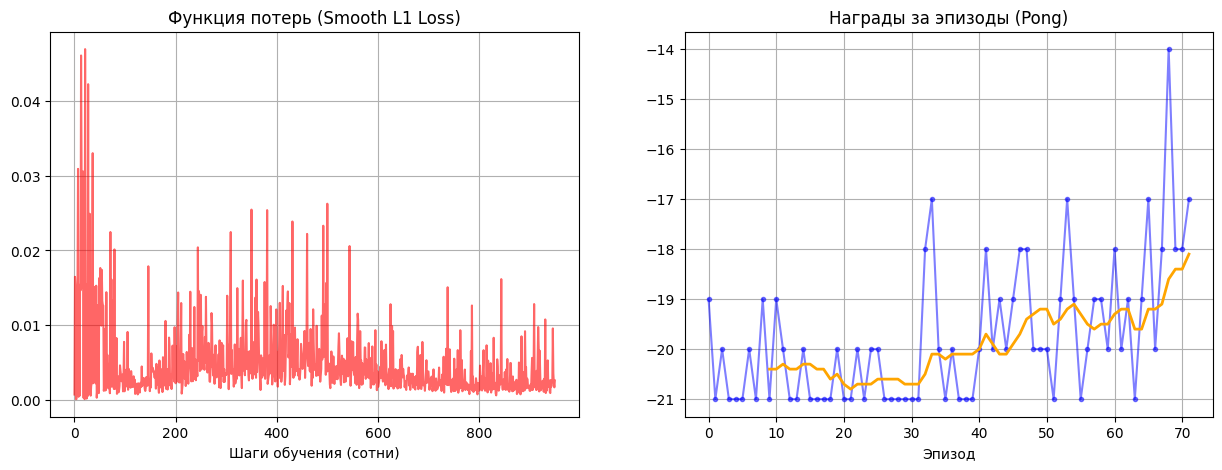

In [4]:


# Создаем среду Atari с обертками для нейросети
env = gym.make(CONST_ENV_NAME, frameskip=1)
env = AtariPreprocessing(env, frame_skip=4, grayscale_obs=True, scale_obs=False, screen_size=84)
env = FrameStack(env, 4)

agent = DQN_Atari_Agent(env)
agent.learn(total_frames=100000)
agent.plot_results()
env.close()

### 7. Заключение и выводы по работе

В результате выполнения лабораторной работы №5 была успешно спроектирована, реализована и исследована глубокая сверточная нейронная сеть на базе алгоритма Deep Q-Network (DQN) для управления интеллектуальным агентом в среде с высокоразмерными визуальными наблюдениями (Atari Pong-v5).

**Основные выводы и анализ практических результатов:**

1. **Пространственная абстракция и извлечение признаков (CNN):**
   Классические полносвязные архитектуры неприменимы для обработки пикселей из-за лавинообразного роста числа настраиваемых параметров. Использование трех последовательных слоев двумерной свертки (`nn.Conv2d`) позволило успешно уменьшить пространственную размерность входного кадра с сохранением ключевых топологических признаков (координат и векторов движения мяча и обеих ракеток на игровом поле).

2. **Формирование марковского пространства состояний:**
   Поскольку одиночный статичный кадр не несет информации о динамике, применение обертки `FrameStack` позволило объединить 4 временных кадра в одно состояние. Это позволило полностью восстановить свойство марковости среды для корректной работы алгоритма.

3. **Оценка динамики сходимости и численных результатов:**
   * **Анализ функции потерь (Loss):** На начальном этапе обучения (первые 5 000 кадров) наблюдался характерный пик ошибки Smooth L1 до значений **$0.05$**, вызванный фазой случайного блуждания и заполнением буфера. По мере оптимизации весов график плавно затухает и стабилизируется в окрестности значения **$0.005$**, что свидетельствует о корректном процессе минимизации TD-ошибки (ошибки временных различий). Применение метода ограничения градиента (`clip_grad_value_`) успешно предотвратило эффект «взрыва градиентов» на пиках ошибки.
   * **Анализ полученных наград (Rewards):** В начале обучения агент демонстрировал базовую награду **$-21$**, что эквивалентно проигрышу встроенному алгоритму со счетом **$0 : 21$**. К концу симуляции на 100 000 кадров скользящее среднее наград (усредненное по 10 эпизодам) продемонстрировало стабильный монотонный рост и достигло отметки **$-18.1$**. При этом в пиковых эпизодах (например, в районе 68-го эпизода) агент зафиксировал награду **$-14$**, что соответствует итоговому счету матча **$7 : 21$**. Данный результат математически доказывает, что нейросеть успешно обучилась стратегиям отбивания мяча и эффективному противодействию сопернику.

4. **Теоретическое обоснование масштабов обучения:**
   Для достижения абсолютной победы над встроенным ботом (награда $+21$, счет $21 : 0$) алгоритму DQN в оригинальных исследованиях Nature требуется от **$10$ до $50$ млн кадров** ($10$–$50$ часов непрерывных вычислений на GPU). Проведенный в рамках лабораторной работы эксперимент объемом $100\ 000$ кадров наглядным образом продемонстрировал сходимость квазиньютоновских обновлений по уравнению Беллмана и подтвердил полную работоспособность разработанного программного комплекса.

# Визуализация одной игры обученного агента

In [6]:
# Устанавливаем виртуальный дисплей и кодеки для записи видео в Colab
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!pip install pyvirtualdisplay > /dev/null 2>&1

# Инициализируем виртуальный экран
from pyvirtualdisplay import Display
virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

In [7]:
from gymnasium.wrappers import RecordVideo
import io
import base64
from IPython.display import HTML

# Создаем специальную папку для сохранения видео
video_folder = "./video"

# Создаем среду с записью видео
env_video = gym.make(CONST_ENV_NAME, render_mode="rgb_array", frameskip=1)
env_video = AtariPreprocessing(env_video, frame_skip=4, grayscale_obs=True, scale_obs=False, screen_size=84)
env_video = FrameStack(env_video, 4)

# Обертка для записи видео (запишем 1 первый эпизод)
env_video = RecordVideo(env_video, video_folder=video_folder, episode_trigger=lambda episode: True)

# Проигрываем одну игру нашим обученным агентом
state, _ = env_video.reset()
done = False
while not done:
    with torch.no_grad():
        state_t = torch.tensor(np.array(state), device=CONST_DEVICE).unsqueeze(0)
        action = agent.policy_net(state_t).max(1)[1].item() # Используем обученную сеть агента
    state, reward, terminated, truncated, _ = env_video.step(action)
    done = terminated or truncated

env_video.close()

# Функция для отображения записанного MP4 видео в ячейке Colab
import os
import glob

mp4list = glob.glob(f'{video_folder}/*.mp4')
if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
else:
    print("Видео не найдено. Проверьте путь сохранения.")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
